# SABR Paper Reproduction Walkthrough

This notebook organizes the current project into a single step-by-step workflow so the paper replication can be run one cell at a time.

Paper:
- Choi, Hu, Kwok, *Efficient and accurate simulation of the stochastic-alpha-beta-rho model*

Project scope:
- core SABR Monte Carlo simulator
- sanity checks for limiting cases and martingale behavior
- paper-style tables and figure datasets
- quick and paper-scale validation hooks


## Contents

1. [Environment and Imports](#1.-Environment-and-Imports)
2. [Project API Overview](#2.-Project-API-Overview)
3. [Core Mathematical Formulas](#3.-Core-Mathematical-Formulas)
4. [Table 3 Cases](#4.-Table-3-Cases)
5. [Sanity Checks](#5.-Sanity-Checks)
6. [Paper Table 1](#6.-Paper-Table-1)
7. [Paper Table 2](#7.-Paper-Table-2)
8. [Paper Figure 1 Dataset](#8.-Paper-Figure-1-Dataset)
9. [Paper Table 4](#9.-Paper-Table-4)
10. [Paper Table 5](#10.-Paper-Table-5)
11. [Paper Table 6](#11.-Paper-Table-6)
12. [Paper Table 7 / Figure 2](#12.-Paper-Table-7-/-Figure-2)
13. [Paper Figure 3](#13.-Paper-Figure-3)
14. [Validation Summary](#14.-Validation-Summary)
15. [Optional CSV Export Helpers](#15.-Optional-CSV-Export-Helpers)


## 1. Environment and Imports

Run this first. It checks the working directory, imports the project module, and shows package versions when available.


In [1]:
from pathlib import Path
import sys
import platform
import importlib

import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Python:', sys.version)
print('Platform:', platform.platform())
print('Project root:', PROJECT_ROOT)

for pkg in ['numpy', 'pandas', 'scipy', 'pyfeng', 'pytest']:
    mod = importlib.import_module(pkg)
    print(f'{pkg}:', getattr(mod, '__version__', 'version unavailable'))


Python: 3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
Project root: c:\Users\zhyim\Desktop\quant\Numeric Method\numerical-project-main\numerical-project-main\numerical-project-main
numpy: 2.2.6
pandas: 2.2.3
scipy: 1.15.3
pyfeng: version unavailable
pytest: 9.0.3


In [2]:
from sabr_replicate import (
    FDMConfig,
    MonteCarloConfig,
    SABRParams,
    case_table_3,
    conditional_integrated_variance_moments,
    european_call_price,
    fdm_benchmark_prices,
    figure1_moment_comparison,
    figure2_runtime_tradeoff,
    finite_difference_call_price,
    martingale_test,
    raw_moments_to_central_stats,
    run_figure3_experiment,
    run_full_validation,
    run_table1_experiment,
    run_table2_experiment,
    run_table4_experiment,
    run_table5_experiment,
    run_table6_experiment,
    run_table7_experiment,
    sample_conditional_integrated_variance,
    simulate_terminal_forward,
    simulate_terminal_forward_islah,
)
import pyfeng as pf


## 2. Project API Overview

This section is only for orientation. It lists the main functions used later in the notebook.


## 3. Core Mathematical Formulas

This section collects the formulas that the implementation is reproducing. In the code, the same objects appear as `SABRParams`, `MonteCarloConfig`, `sample_conditional_integrated_variance`, `sample_cev_exact`, and `simulate_terminal_forward`.

### 3.1 SABR model

The SABR dynamics are

$$
dF_t = \sigma_t F_t^\beta\, dW_t,
\qquad
\frac{d\sigma_t}{\sigma_t} = \nu\, dZ_t,
\qquad
dW_t\,dZ_t = \rho\,dt .
$$

The exact volatility step over one interval of length $h$ is

$$
\sigma_{t+h}
=
\sigma_t
\exp\left(\nu\sqrt{h}X_\sigma - \frac{1}{2}\nu^2 h\right),
\qquad X_\sigma \sim N(0,1).
$$

We use

$$
\hat\nu = \nu\sqrt{h},
\qquad
\beta^* = 1-\beta,
\qquad
\rho^* = \sqrt{1-\rho^2}.
$$

### 3.2 Algorithm 1: conditional average variance

After sampling $\sigma_{t+h}$, the first hard quantity is the normalized conditional average variance

$$
I_t^h
=
\frac{1}{\sigma_t^2 h}
\int_t^{t+h} \sigma_s^2\,ds
\;\Bigg|\;\sigma_{t+h}.
$$

Let

$$
\mu = \mathbb{E}\left[I_t^h \mid \sigma_{t+h}\right],
\qquad
v =
\frac{
\sqrt{\mathrm{Var}\left(I_t^h \mid \sigma_{t+h}\right)}
}{
\mathbb{E}\left[I_t^h \mid \sigma_{t+h}\right]
}.
$$

With fixed shift

$$
\lambda = \frac{5}{6},
$$

the lognormal shape parameter is

$$
a
=
\sqrt{\log\left(1 + \frac{v^2}{\lambda^2}\right)}
=
\sqrt{\log\left(1 + \frac{36}{25}v^2\right)}.
$$

Algorithm 1 samples

$$
I_t^h
\approx
\mu
\left[
\frac{1}{6}
+
\frac{5}{6}
\exp\left(aX - \frac{1}{2}a^2\right)
\right],
\qquad X\sim N(0,1).
$$

In the implementation, `conditional_integrated_variance_moments` supplies the moments and `sample_conditional_integrated_variance` performs this shifted-lognormal sampling.

### 3.3 Algorithm 2: martingale-preserving CEV approximation

For $0<\beta<1$, conditional on $\sigma_{t+h}$ and $I_t^h$,

$$
F_{t+h}\mid \sigma_{t+h}, I_t^h
\approx
\mathrm{CEV}_\beta\left(\bar F_t^h, (\rho^*)^2\sigma_t^2 h I_t^h\right).
$$

The conditional mean is

$$
\bar F_t^h
\approx
F_t
\exp\left(
\frac{\rho(\sigma_{t+h}-\sigma_t)}{\nu F_t^{\beta^*}}
-
\frac{\rho^2\sigma_t^2 h I_t^h}{2F_t^{2\beta^*}}
\right).
$$

This construction is meant to preserve the martingale condition:

$$
\mathbb{E}[F_{t+h}\mid \sigma_{t+h}, I_t^h] = \bar F_t^h,
\qquad
\mathbb{E}[F_{t+h}] = F_t.
$$

For the lognormal special case $\beta=1$,

$$
F_{t+h}
=
\bar F_t^h
\exp\left(
\rho^*\sigma_t\sqrt{hI_t^h}X
-
\frac{1}{2}(\rho^*)^2\sigma_t^2 hI_t^h
\right),
\qquad X\sim N(0,1).
$$

### 3.4 Algorithm 3: exact CEV sampling

For
$$
F_T \sim \mathrm{CEV}_\beta(F_0, \sigma_0^2T),
$$

define
$$
\alpha = \frac{1}{2\beta^*},
\qquad
z_0 = \frac{F_0^{2\beta^*}}{(\beta^*)^2\sigma_0^2T}.
$$

Sample
$$
X \sim \Gamma(\alpha,1),
$$
where $\Gamma(\alpha,1)$ denotes a Gamma distribution with shape $\alpha$ and unit scale.

If $X \ge z_0/2$, set $F_T = 0$ (absorbing boundary). Otherwise sample
$$
N \sim \mathrm{Poisson}(z_0/2 - X),
\qquad
z_T \sim 2\Gamma(N+1,1),
$$

and return
$$
F_T = \left((\beta^*)^2\sigma_0^2Tz_T\right)^{1/(2\beta^*)}.
$$

This provides an exact sampling scheme for the CEV distribution via a Poisson–Gamma mixture representation.

Inside SABR, this sampler is applied with
$$
F_0 \leftarrow \bar F_t^h,
\qquad
\sigma_0^2T \leftarrow (\rho^*)^2\sigma_t^2hI_t^h.
$$

### 3.5 Algorithm 4: full simulation over a time grid

For each time step:

1. Sample $\sigma_{t+h}$ exactly.
2. Sample $I_t^h$ using Algorithm 1.
3. Compute $\bar F_t^h$ using Algorithm 2.
4. Sample $F_{t+h}$ using Algorithm 3.
5. Repeat until maturity $T$.

The Monte Carlo European call estimator is

$$
\widehat C(K)
=
\frac{1}{N}\sum_{i=1}^N \max(F_T^{(i)}-K,0).
$$

The reported errors are

$$
\text{bias} = \widehat C - C_{\text{benchmark}},
\qquad
\text{relative error} = \frac{\widehat C-C_{\text{benchmark}}}{C_{\text{benchmark}}},
$$

$$
\text{RMS error} = \sqrt{\text{bias}^2 + \text{stdev}^2}.
$$

The martingale check verifies numerically that

$$
\mathbb{E}[F_T] = F_0.
$$


In [3]:
api_overview = pd.DataFrame(
    [
        ('simulate_terminal_forward', 'Main SABR Monte Carlo terminal simulator using the paper scheme'),
        ('simulate_terminal_forward_islah', 'Appendix B / Islah-style comparison branch'),
        ('sample_conditional_integrated_variance', 'Algorithm 1 style conditional average-variance sampling'),
        ('conditional_integrated_variance_moments', 'Conditional raw moments of normalized average variance'),
        ('run_table1_experiment', 'Paper Table 1 dataset'),
        ('run_table2_experiment', 'Paper Table 2 dataset'),
        ('run_table4_experiment', 'Paper Table 4 dataset'),
        ('run_table5_experiment', 'Paper Table 5 dataset'),
        ('run_table6_experiment', 'Paper Table 6 dataset'),
        ('run_table7_experiment', 'Paper Table 7 / Figure 2 dataset'),
        ('run_figure3_experiment', 'Paper Figure 3 dataset'),
        ('run_full_validation', 'Repository validation harness'),
    ],
    columns=['function', 'purpose'],
)
api_overview


,function,purpose
0,simulate_terminal_forward,Main SABR Monte Carlo terminal simulator using...
1,simulate_terminal_forward_islah,Appendix B / Islah-style comparison branch
2,sample_conditional_integrated_variance,Algorithm 1 style conditional average-variance...
3,conditional_integrated_variance_moments,Conditional raw moments of normalized average ...
4,run_table1_experiment,Paper Table 1 dataset
5,run_table2_experiment,Paper Table 2 dataset
6,run_table4_experiment,Paper Table 4 dataset
7,run_table5_experiment,Paper Table 5 dataset
8,run_table6_experiment,Paper Table 6 dataset
9,run_table7_experiment,Paper Table 7 / Figure 2 dataset


## 4. Table 3 Cases

These are the paper parameter presets used throughout later sections.


In [4]:
case_df = pd.DataFrame(case_table_3()).T
case_df.index.name = 'case'
case_df


,f0,sigma0,nu,rho,beta,maturity
case,,,,,,
Case I,1.00,0.25,0.3,-0.8,0.3,10.0
Case II,1.00,0.25,0.3,-0.5,0.6,10.0
Case III,0.05,0.40,0.6,0.0,0.3,1.0
Case IV,1.10,0.40,0.8,-0.3,0.3,4.0
Case V,1.10,0.30,0.5,-0.8,0.4,10.0


## 5. Sanity Checks

These cells verify model-level behavior that should hold independently of the paper tables.


### 5.1 `nu = 0` should reduce SABR to CEV


In [5]:
params = SABRParams(f0=1.0, sigma0=0.25, nu=0.0, rho=-0.4, beta=0.3)
mc = MonteCarloConfig(maturity=1.0, step=1.0, n_paths=200_000, seed=12345)
strikes = np.array([0.6, 1.0, 1.4])

terminal = simulate_terminal_forward(params, mc)
mc_prices = np.array([european_call_price(terminal, k) for k in strikes])
cev_prices = pf.Cev(sigma=params.sigma0, beta=params.beta, is_fwd=True).price(strikes, params.f0, mc.maturity)

pd.DataFrame({
    'strike': strikes,
    'mc_price': mc_prices,
    'cev_price': cev_prices,
    'error': mc_prices - cev_prices,
})


,strike,mc_price,cev_price,error
0,0.6,0.404583,0.404036,0.000547
1,1.0,0.099984,0.099602,0.000382
2,1.4,0.007369,0.007385,-0.000016


### 5.2 `beta = 1, nu = 0` should reduce SABR to Black-Scholes / lognormal


In [6]:
params = SABRParams(f0=1.0, sigma0=0.2, nu=0.0, rho=-0.75, beta=1.0)
mc = MonteCarloConfig(maturity=1.0, step=1.0, n_paths=200_000, seed=12345)
strikes = np.array([0.8, 1.0, 1.2])

terminal = simulate_terminal_forward(params, mc)
mc_prices = np.array([european_call_price(terminal, k) for k in strikes])
bsm_prices = pf.Bsm(sigma=params.sigma0, is_fwd=True).price(strikes, params.f0, mc.maturity)

pd.DataFrame({
    'strike': strikes,
    'mc_price': mc_prices,
    'bsm_price': bsm_prices,
    'error': mc_prices - bsm_prices,
})


,strike,mc_price,bsm_price,error
0,0.8,0.212078,0.211859,0.000219
1,1.0,0.079613,0.079656,-0.000043
2,1.2,0.021431,0.021473,-0.000042


### 5.3 Conditional average-variance moment spot check

This is a small diagnostic cell for the `I_t^h` machinery used inside the full simulator.


In [7]:
sigma_t = np.array([0.2])
sigma_next = np.array([0.24])
nu = 0.4
h = 1.0

mu1, mu2_raw, mu3_raw, mu4_raw = conditional_integrated_variance_moments(sigma_t, sigma_next, nu, h)
mean, var, std, cv, skewness, ex_kurtosis = raw_moments_to_central_stats(mu1, mu2_raw, mu3_raw, mu4_raw)

pd.DataFrame({
    'mu1': mu1,
    'mu2_raw': mu2_raw,
    'mu3_raw': mu3_raw,
    'mu4_raw': mu4_raw,
    'var': var,
    'std': std,
    'cv': cv,
    'skewness': skewness,
    'ex_kurtosis': ex_kurtosis,
})


,mu1,mu2_raw,mu3_raw,mu4_raw,var,std,cv,skewness,ex_kurtosis
0,1.272973,1.712454,2.438791,3.683759,0.091994,0.303305,0.238265,0.884234,1.467284


### 5.4 Martingale sanity check


In [8]:
case_v = case_table_3()['Case V']
params = SABRParams(
    f0=case_v['f0'],
    sigma0=case_v['sigma0'],
    nu=case_v['nu'],
    rho=case_v['rho'],
    beta=case_v['beta'],
)

martingale_test(params, maturities=[1, 2, 4, 6, 8, 10], step=1.0, n_paths=30_000, seed0=101)


,maturity,mean_terminal,std_terminal,stderr_terminal,martingale_error,z_score,runtime_sec,step,n_paths,conclusion
0,1.0,1.098478,0.305621,0.001765,-0.001522,-0.862636,0.011320,1.0,30000,Monte Carlo noise dominated
1,2.0,1.102482,0.422185,0.002437,0.002482,1.018128,0.021563,1.0,30000,Monte Carlo noise dominated
2,4.0,1.107439,0.563293,0.003252,0.007439,2.287301,0.040614,1.0,30000,Monte Carlo noise dominated
3,6.0,1.105598,0.643586,0.003716,0.005598,1.506589,0.058985,1.0,30000,Monte Carlo noise dominated
4,8.0,1.101523,0.703496,0.004062,0.001523,0.374890,0.077913,1.0,30000,Monte Carlo noise dominated
5,10.0,1.099555,0.741081,0.004279,-0.000445,-0.103937,0.094923,1.0,30000,Monte Carlo noise dominated


### 5.5 `|rho| = 1` Islah edge case stability


In [9]:
rows = []
for beta in (0.4, 0.6, 0.8):
    params = SABRParams(f0=1.0, sigma0=0.2, nu=0.2, rho=1.0, beta=beta)
    mc = MonteCarloConfig(maturity=1.0, step=1.0, n_paths=5_000, seed=123)
    terminal = simulate_terminal_forward_islah(params, mc)
    rows.append({
        'beta': beta,
        'all_finite': bool(np.isfinite(terminal).all()),
        'all_nonnegative': bool((terminal >= 0.0).all()),
        'mean_terminal': float(np.mean(terminal)),
        'min_terminal': float(np.min(terminal)),
    })

pd.DataFrame(rows)


,beta,all_finite,all_nonnegative,mean_terminal,min_terminal
0,0.4,True,True,1.009120,0.536459
1,0.6,True,True,1.013306,0.558478
2,0.8,True,True,1.017677,0.577711


## 6. Paper Table 1

By default, this uses the paper table benchmarks embedded in the repo. To compare against the repo PDE benchmark instead, run the later FDM cells or pass benchmark providers in standalone scripts.


In [10]:
table1_df = run_table1_experiment(n_paths=100_000, n_repeats=50, seed0=12345)
table1_df


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,maturity,runtime_sec_mean,benchmark_price,bias,relative_error,rho,nu,beta
0,1.0,0.079139,0.000350,1.000117,0.000676,0.000049,0.000096,50.0,100000.0,1.00,1.0,0.028844,0.07910,0.000039,0.000497,-0.75,0.2,1.0
1,1.0,0.079153,0.000368,1.000035,0.000651,0.000052,0.000092,50.0,100000.0,0.50,1.0,0.050367,0.07910,0.000053,0.000668,-0.75,0.2,1.0
2,1.0,0.079105,0.000403,1.000101,0.000647,0.000057,0.000091,50.0,100000.0,0.25,1.0,0.097032,0.07910,0.000005,0.000067,-0.75,0.2,1.0
3,1.0,0.079425,0.000334,0.999981,0.000583,0.000047,0.000082,50.0,100000.0,1.00,1.0,0.025374,0.07942,0.000005,0.000057,-0.50,0.2,1.0
4,1.0,0.079858,0.000353,1.000222,0.000623,0.000050,0.000088,50.0,100000.0,1.00,1.0,0.025411,0.07969,0.000168,0.002107,-0.25,0.2,1.0
5,1.0,0.078509,0.000340,0.999892,0.000602,0.000048,0.000085,50.0,100000.0,1.00,1.0,0.025969,0.07860,-0.000091,-0.001152,-0.75,0.4,1.0
6,1.0,0.078056,0.000325,0.999862,0.000635,0.000046,0.000090,50.0,100000.0,1.00,1.0,0.027571,0.07811,-0.000054,-0.000694,-0.75,0.6,1.0


## 7. Paper Table 2


In [11]:
table2_df = run_table2_experiment(n_paths=100_000, n_repeats=50, seed0=12345)
table2_df


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,maturity,runtime_sec_mean,benchmark_price,bias,relative_error,rho,nu,beta
0,1.0,0.080272,0.000465,0.999916,0.000687,0.000066,0.000097,50.0,100000.0,1.00,1.0,0.024922,0.07989,0.000382,0.004786,1.00,0.2,0.4
1,1.0,0.080308,0.000564,0.999972,0.000845,0.000080,0.000119,50.0,100000.0,1.00,1.0,0.024799,0.08002,0.000288,0.003605,1.00,0.2,0.6
2,1.0,0.080416,0.000479,1.000109,0.000634,0.000068,0.000090,50.0,100000.0,1.00,1.0,0.025162,0.08017,0.000246,0.003071,1.00,0.2,0.8
3,1.0,0.080746,0.000626,0.999897,0.000775,0.000089,0.000110,50.0,100000.0,1.00,1.0,0.029140,0.08044,0.000306,0.003809,1.00,0.4,0.8
4,1.0,0.080668,0.001318,0.999282,0.001365,0.000186,0.000193,50.0,100000.0,1.00,1.0,0.032044,0.08043,0.000238,0.002958,1.00,0.8,0.8
5,1.0,0.080169,0.000431,0.999867,0.000646,0.000061,0.000091,50.0,100000.0,0.50,1.0,0.055533,0.07989,0.000279,0.003489,1.00,0.2,0.4
6,1.0,0.080356,0.000428,1.000160,0.000645,0.000061,0.000091,50.0,100000.0,0.50,1.0,0.051801,0.08002,0.000336,0.004204,1.00,0.2,0.6
7,1.0,0.080461,0.000555,1.000217,0.000782,0.000079,0.000111,50.0,100000.0,0.50,1.0,0.052501,0.08017,0.000291,0.003629,1.00,0.2,0.8
8,1.0,0.080583,0.000517,0.999917,0.000736,0.000073,0.000104,50.0,100000.0,0.50,1.0,0.054774,0.08044,0.000143,0.001780,1.00,0.4,0.8
9,1.0,0.081096,0.002270,1.000229,0.002316,0.000321,0.000328,50.0,100000.0,0.50,1.0,0.059352,0.08043,0.000666,0.008275,1.00,0.8,0.8


## 8. Paper Figure 1 Dataset

This generates the skewness and ex-kurtosis comparison data used for the figure. Plotting is optional; the dataset itself is enough for validation.


In [12]:
figure1_df = figure1_moment_comparison(hat_nu=0.4)
figure1_df.head(12)


,z_hat,hat_nu,exact_cv,exact_skewness,exact_ex_kurtosis,ln_skewness,ln_ex_kurtosis,sln_fixed_lambda,sln_fixed_skewness,sln_fixed_ex_kurtosis,sln_exact_lambda,sln_exact_skewness,sln_exact_ex_kurtosis
0,-4.00,0.4,0.221074,0.830203,1.295462,0.674025,0.818511,0.833333,0.814535,1.202457,0.818301,0.830203,1.250066
1,-3.95,0.4,0.221439,0.831368,1.299060,0.675175,0.821343,0.833333,0.815943,1.206697,0.818558,0.831368,1.253642
2,-3.90,0.4,0.221803,0.832526,1.302642,0.676320,0.824167,0.833333,0.817345,1.210924,0.818813,0.832526,1.257205
3,-3.85,0.4,0.222164,0.833677,1.306209,0.677459,0.826982,0.833333,0.818740,1.215139,0.819068,0.833677,1.260753
4,-3.80,0.4,0.222524,0.834822,1.309760,0.678592,0.829788,0.833333,0.820128,1.219341,0.819322,0.834822,1.264285
5,-3.75,0.4,0.222882,0.835959,1.313293,0.679719,0.832583,0.833333,0.821509,1.223527,0.819574,0.835959,1.267800
6,-3.70,0.4,0.223238,0.837090,1.316808,0.680840,0.835367,0.833333,0.822882,1.227698,0.819825,0.837090,1.271299
7,-3.65,0.4,0.223592,0.838213,1.320305,0.681954,0.838140,0.833333,0.824247,1.231853,0.820075,0.838213,1.274779
8,-3.60,0.4,0.223944,0.839328,1.323782,0.683062,0.840901,0.833333,0.825604,1.235990,0.820323,0.839328,1.278241
9,-3.55,0.4,0.224293,0.840436,1.327238,0.684162,0.843650,0.833333,0.826952,1.240108,0.820570,0.840436,1.281683


Text(0, 0.5, 'skewness')

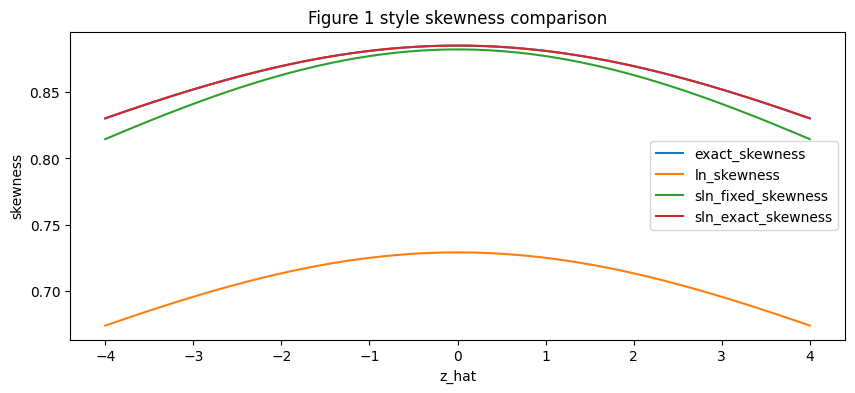

In [13]:
ax = figure1_df.plot(x='z_hat', y=['exact_skewness', 'ln_skewness', 'sln_fixed_skewness', 'sln_exact_skewness'], figsize=(10, 4), title='Figure 1 style skewness comparison')
ax.set_ylabel('skewness')


## 9. Paper Table 4

Case I. This includes the simulated rows and the available analytic comparison rows.


In [14]:
table4_df = run_table4_experiment(n_paths=100_000, n_repeats=50, seed0=12345)
table4_df


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,...,runtime_sec_mean,benchmark_price,bias,relative_error,table,case,model,source,bias_x1e3,strike_ratio
0,0.2,0.841386,0.001469,1.000154,0.001619,0.000208,0.000229,50.0,100000.0,1.0000,...,0.353317,0.84255,-0.001164,-0.001382,Table 4,Case I,Our method,simulated,-1.164347,0.2
1,0.4,0.687609,0.001344,1.000154,0.001619,0.000190,0.000229,50.0,100000.0,1.0000,...,0.353317,0.68906,-0.001451,-0.002105,Table 4,Case I,Our method,simulated,-1.450632,0.4
2,0.8,0.406104,0.001130,1.000154,0.001619,0.000160,0.000229,50.0,100000.0,1.0000,...,0.353317,0.40646,-0.000356,-0.000876,Table 4,Case I,Our method,simulated,-0.356245,0.8
3,1.0,0.285586,0.001022,1.000154,0.001619,0.000144,0.000229,50.0,100000.0,1.0000,...,0.353317,0.28502,0.000566,0.001984,Table 4,Case I,Our method,simulated,0.565541,1.0
4,1.2,0.184434,0.000887,1.000154,0.001619,0.000126,0.000229,50.0,100000.0,1.0000,...,0.353317,0.18304,0.001394,0.007614,Table 4,Case I,Our method,simulated,1.393750,1.2
5,1.6,0.055161,0.000555,1.000154,0.001619,0.000079,0.000229,50.0,100000.0,1.0000,...,0.353317,0.05343,0.001731,0.032403,Table 4,Case I,Our method,simulated,1.731268,1.6
6,2.0,0.012272,0.000335,1.000154,0.001619,0.000047,0.000229,50.0,100000.0,1.0000,...,0.353317,0.01096,0.001312,0.119750,Table 4,Case I,Our method,simulated,1.312460,2.0
7,0.2,0.842273,0.001937,0.999688,0.002106,0.000274,0.000298,50.0,100000.0,0.2500,...,1.379122,0.84255,-0.000277,-0.000328,Table 4,Case I,Our method,simulated,-0.276534,0.2
8,0.4,0.688988,0.001768,0.999688,0.002106,0.000250,0.000298,50.0,100000.0,0.2500,...,1.379122,0.68906,-0.000072,-0.000105,Table 4,Case I,Our method,simulated,-0.072494,0.4
9,0.8,0.406849,0.001371,0.999688,0.002106,0.000194,0.000298,50.0,100000.0,0.2500,...,1.379122,0.40646,0.000389,0.000958,Table 4,Case I,Our method,simulated,0.389388,0.8


## 10. Paper Table 5

Case II.


In [15]:
table5_df = run_table5_experiment(n_paths=100_000, n_repeats=50, seed0=12345)
table5_df


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,...,runtime_sec_mean,benchmark_price,bias,relative_error,table,case,model,source,bias_x1e3,strike_ratio
0,0.2,0.828431,0.002638,0.999924,0.002779,0.000373,0.000393,50.0,100000.0,1.0000,...,0.369543,0.82886,-0.000429,-0.000518,Table 5,Case II,Our method,simulated,-0.429065,0.2
1,0.4,0.669050,0.002483,0.999924,0.002779,0.000351,0.000393,50.0,100000.0,1.0000,...,0.369543,0.66959,-0.000540,-0.000807,Table 5,Case II,Our method,simulated,-0.540204,0.4
2,0.8,0.397216,0.002109,0.999924,0.002779,0.000298,0.000393,50.0,100000.0,1.0000,...,0.369543,0.39772,-0.000504,-0.001266,Table 5,Case II,Our method,simulated,-0.503561,0.8
3,1.0,0.290768,0.001922,0.999924,0.002779,0.000272,0.000393,50.0,100000.0,1.0000,...,0.369543,0.29118,-0.000412,-0.001416,Table 5,Case II,Our method,simulated,-0.412312,1.0
4,1.2,0.206575,0.001713,0.999924,0.002779,0.000242,0.000393,50.0,100000.0,1.0000,...,0.369543,0.20690,-0.000325,-0.001570,Table 5,Case II,Our method,simulated,-0.324837,1.2
5,1.6,0.099993,0.001296,0.999924,0.002779,0.000183,0.000393,50.0,100000.0,1.0000,...,0.369543,0.10018,-0.000187,-0.001870,Table 5,Case II,Our method,simulated,-0.187298,1.6
6,2.0,0.050052,0.000957,0.999924,0.002779,0.000135,0.000393,50.0,100000.0,1.0000,...,0.369543,0.05014,-0.000088,-0.001760,Table 5,Case II,Our method,simulated,-0.088229,2.0
7,0.2,0.828341,0.002727,0.999600,0.002858,0.000386,0.000404,50.0,100000.0,0.2500,...,1.410825,0.82886,-0.000519,-0.000626,Table 5,Case II,Our method,simulated,-0.519055,0.2
8,0.4,0.669095,0.002544,0.999600,0.002858,0.000360,0.000404,50.0,100000.0,0.2500,...,1.410825,0.66959,-0.000495,-0.000739,Table 5,Case II,Our method,simulated,-0.494752,0.4
9,0.8,0.397287,0.002099,0.999600,0.002858,0.000297,0.000404,50.0,100000.0,0.2500,...,1.410825,0.39772,-0.000433,-0.001089,Table 5,Case II,Our method,simulated,-0.433034,0.8


## 11. Paper Table 6

Case III. This is the runtime / bias comparison against paper-reference baseline rows.


In [16]:
table6_df = run_table6_experiment(n_paths=100_000, n_repeats=50, seed0=12345)
table6_df


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,...,runtime_sec_mean,benchmark_price,bias,relative_error,table,case,model,source,bias_x1e3,strike_ratio
0,0.02,0.045671,0.000404,0.05008,0.000423,0.000057,0.00006,50.0,100000.0,1.000000,...,0.029542,0.04559,0.000081,0.001769,Table 6,Case III,Our method,simulated,0.080650,0.4
1,0.04,0.041486,0.000384,0.05008,0.000423,0.000054,0.00006,50.0,100000.0,1.000000,...,0.029542,0.04141,0.000076,0.001829,Table 6,Case III,Our method,simulated,0.075730,0.8
2,0.05,0.039496,0.000373,0.05008,0.000423,0.000053,0.00006,50.0,100000.0,1.000000,...,0.029542,0.03942,0.000076,0.001936,Table 6,Case III,Our method,simulated,0.076307,1.0
3,0.06,0.037580,0.000363,0.05008,0.000423,0.000051,0.00006,50.0,100000.0,1.000000,...,0.029542,0.03750,0.000080,0.002134,Table 6,Case III,Our method,simulated,0.080029,1.2
4,0.08,0.033977,0.000346,0.05008,0.000423,0.000049,0.00006,50.0,100000.0,1.000000,...,0.029542,0.03390,0.000077,0.002260,Table 6,Case III,Our method,simulated,0.076619,1.6
5,0.10,0.030678,0.000331,0.05008,0.000423,0.000047,0.00006,50.0,100000.0,1.000000,...,0.029542,0.03061,0.000068,0.002219,Table 6,Case III,Our method,simulated,0.067938,2.0
6,0.02,0.047190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002500,...,4.120000,0.04559,0.001600,NaN,Table 6,Case III,Euler,paper_reference,1.600000,0.4
7,0.04,0.042910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002500,...,4.120000,0.04141,0.001500,NaN,Table 6,Case III,Euler,paper_reference,1.500000,0.8
8,0.05,0.040920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002500,...,4.120000,0.03942,0.001500,NaN,Table 6,Case III,Euler,paper_reference,1.500000,1.0
9,0.06,0.038900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002500,...,4.120000,0.03750,0.001400,NaN,Table 6,Case III,Euler,paper_reference,1.400000,1.2


## 12. Paper Table 7 / Figure 2

This section can be slow. It reproduces the convergence and runtime trade-off dataset.


In [23]:
table7_df = run_table7_experiment(
    n_paths_base=160_000,
    n_repeats=10,
    seed0=12345,
    benchmark_source='fdm',
)
table7_df


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,...,benchmark_price,bias,relative_error,table,case,model,source,benchmark_note,rms_error,rms_error_x1e3
0,1.1,0.297433,0.001511,1.099258,0.001851,0.000478,0.000585,10.0,160000.0,1.0000,...,0.301605,-0.004172,-0.013831,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.004437,4.436887
1,1.1,0.299114,0.001680,1.100110,0.002196,0.000531,0.000694,10.0,320000.0,0.5000,...,0.301605,-0.002490,-0.008257,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.003004,3.004110
2,1.1,0.299747,0.000786,1.099995,0.000858,0.000249,0.000271,10.0,640000.0,0.2500,...,0.301605,-0.001858,-0.006159,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.002017,2.016914
3,1.1,0.300085,0.000580,1.100166,0.000797,0.000183,0.000252,10.0,1280000.0,0.1250,...,0.301605,-0.001520,-0.005039,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.001627,1.626754
4,1.1,0.300494,0.000407,1.100152,0.000547,0.000129,0.000173,10.0,2560000.0,0.0625,...,0.301605,-0.001111,-0.003683,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.001183,1.183106
5,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160000.0,1.0000,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.003270,3.270000
6,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,320000.0,0.5000,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.001940,1.940000
7,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,640000.0,0.2500,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.001210,1.210000
8,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1280000.0,0.1250,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.000860,0.860000
9,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2560000.0,0.0625,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.000590,0.590000


In [24]:
figure2_df = figure2_runtime_tradeoff(
    n_paths_base=160_000,
    n_repeats=10,
    seed0=12345,
    benchmark_source='fdm',
)
figure2_df


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,...,benchmark_price,bias,relative_error,table,case,model,source,benchmark_note,rms_error,rms_error_x1e3
0,1.1,0.297433,0.001511,1.099258,0.001851,0.000478,0.000585,10.0,160000.0,1.0000,...,0.301605,-0.004172,-0.013831,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.004437,4.436887
1,1.1,0.299114,0.001680,1.100110,0.002196,0.000531,0.000694,10.0,320000.0,0.5000,...,0.301605,-0.002490,-0.008257,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.003004,3.004110
2,1.1,0.299747,0.000786,1.099995,0.000858,0.000249,0.000271,10.0,640000.0,0.2500,...,0.301605,-0.001858,-0.006159,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.002017,2.016914
3,1.1,0.300085,0.000580,1.100166,0.000797,0.000183,0.000252,10.0,1280000.0,0.1250,...,0.301605,-0.001520,-0.005039,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.001627,1.626754
4,1.1,0.300494,0.000407,1.100152,0.000547,0.000129,0.000173,10.0,2560000.0,0.0625,...,0.301605,-0.001111,-0.003683,Table 7,Case IV,Our method,simulated,PDE/FDM benchmark,0.001183,1.183106
5,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160000.0,1.0000,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.003270,3.270000
6,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,320000.0,0.5000,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.001940,1.940000
7,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,640000.0,0.2500,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.001210,1.210000
8,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1280000.0,0.1250,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.000860,0.860000
9,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2560000.0,0.0625,...,NaN,NaN,NaN,Table 7,Case IV,Our method (paper reference),paper_reference,paper FDM benchmark,0.000590,0.590000


### Figure 2 Plot

This turns the Table 7 / Figure 2 dataset into the paper-style runtime versus RMS error view.

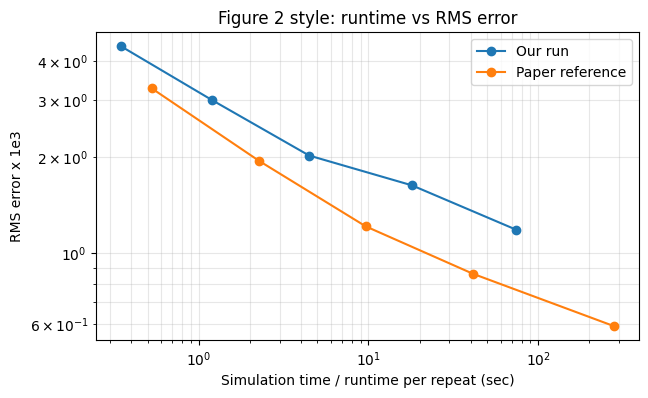

In [25]:
import matplotlib.pyplot as plt

fig2_plot_df = figure2_df.dropna(subset=['runtime_sec_mean', 'rms_error_x1e3']).copy()
fig2_plot_df['series'] = fig2_plot_df['source'].map({
    'simulated': 'Our run',
    'paper_reference': 'Paper reference',
}).fillna(fig2_plot_df['source'])

fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in fig2_plot_df.groupby('series'):
    grp = grp.sort_values('runtime_sec_mean')
    ax.plot(grp['runtime_sec_mean'], grp['rms_error_x1e3'], marker='o', label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Simulation time / runtime per repeat (sec)')
ax.set_ylabel('RMS error x 1e3')
ax.set_title('Figure 2 style: runtime vs RMS error')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.show()

## 13. Paper Figure 3

This compares the paper scheme against the Islah approximation across maturities.


In [20]:
figure3_df = run_figure3_experiment(
    n_paths=100_000,
    n_repeats=2,
    seed0=12345,
    benchmark_source='mc',
)
figure3_df.head(20)


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,...,runtime_sec_mean,benchmark_price,bias,relative_error,figure,case,model,benchmark_note,forward_error,option_error
0,1.1,0.120807,0.000117,1.100169,0.000241,0.000083,0.000170,2.0,100000.0,1.0,...,0.034032,0.122530,-0.001722,-0.014057,Figure 3,Case V,Our method,internal high-resolution MC (h=0.25),0.000169,-0.001722
1,1.1,0.122411,0.000013,1.101346,0.000469,0.000009,0.000331,2.0,100000.0,0.5,...,0.063523,0.122530,-0.000119,-0.000971,Figure 3,Case V,Our method,internal high-resolution MC (h=0.25),0.001346,-0.000119
2,1.1,0.123798,0.000330,1.101244,0.001564,0.000233,0.001106,2.0,100000.0,1.0,...,0.034928,0.122530,0.001268,0.010347,Figure 3,Case V,Islah,internal high-resolution MC (h=0.25),0.001244,0.001268
3,1.1,0.122400,0.000282,1.100178,0.000088,0.000199,0.000062,2.0,100000.0,0.5,...,0.067190,0.122530,-0.000130,-0.001059,Figure 3,Case V,Islah,internal high-resolution MC (h=0.25),0.000178,-0.000130
4,1.1,0.169575,0.001622,1.101238,0.000753,0.001147,0.000533,2.0,100000.0,1.0,...,0.066054,0.170012,-0.000436,-0.002567,Figure 3,Case V,Our method,internal high-resolution MC (h=0.25),0.001238,-0.000436
5,1.1,0.170013,0.001316,1.100805,0.002876,0.000931,0.002034,2.0,100000.0,0.5,...,0.124796,0.170012,0.000002,0.000010,Figure 3,Case V,Our method,internal high-resolution MC (h=0.25),0.000805,0.000002
6,1.1,0.172199,0.000409,1.103776,0.000925,0.000290,0.000654,2.0,100000.0,1.0,...,0.068221,0.170012,0.002188,0.012868,Figure 3,Case V,Islah,internal high-resolution MC (h=0.25),0.003776,0.002188
7,1.1,0.170920,0.000514,1.100593,0.001792,0.000363,0.001267,2.0,100000.0,0.5,...,0.130604,0.170012,0.000908,0.005342,Figure 3,Case V,Islah,internal high-resolution MC (h=0.25),0.000593,0.000908
8,1.1,0.202486,0.000856,1.100196,0.002072,0.000605,0.001465,2.0,100000.0,1.0,...,0.098922,0.203895,-0.001410,-0.006915,Figure 3,Case V,Our method,internal high-resolution MC (h=0.25),0.000196,-0.001410
9,1.1,0.204208,0.000492,1.100344,0.001123,0.000348,0.000794,2.0,100000.0,0.5,...,0.188032,0.203895,0.000312,0.001531,Figure 3,Case V,Our method,internal high-resolution MC (h=0.25),0.000344,0.000312


In [21]:
pivot_forward = figure3_df.pivot_table(index='maturity', columns=['model', 'step'], values='forward_error')
pivot_option = figure3_df.pivot_table(index='maturity', columns=['model', 'step'], values='option_error')

display(pivot_forward)
display(pivot_option)


model        Islah           Our method          
step           0.5       1.0        0.5       1.0
maturity                                         
1.0       0.000178  0.001244   0.001346  0.000169
2.0       0.000593  0.003776   0.000805  0.001238
3.0       0.004225  0.007481   0.000344  0.000196
4.0       0.005687  0.014438  -0.000672  0.000914
5.0       0.008603  0.021496   0.002182  0.000825
6.0       0.012028  0.019486  -0.001456 -0.001132
7.0       0.011979  0.022636   0.000339  0.000307
8.0       0.008953  0.026240   0.000749  0.000742
9.0       0.013566  0.027959  -0.000119  0.000848
10.0      0.017841  0.029364   0.000903  0.000414

model        Islah           Our method          
step           0.5       1.0        0.5       1.0
maturity                                         
1.0      -0.000130  0.001268  -0.000119 -0.001722
2.0       0.000908  0.002188   0.000002 -0.000436
3.0       0.001040  0.002609   0.000312 -0.001410
4.0       0.002029  0.006430  -0.000357 -0.000751
5.0       0.002828  0.009417   0.001769 -0.001635
6.0       0.003766  0.007039  -0.002647 -0.002522
7.0       0.003058  0.008933  -0.001836 -0.003098
8.0       0.002350  0.011927  -0.000730 -0.002448
9.0       0.004702  0.013466  -0.001178 -0.002970
10.0      0.008577  0.014971  -0.000165 -0.002249

### Figure 3 Plots

These plots recreate the paper-style Figure 3 comparison: panel (a) is forward-price error, and panel (b) is ATM option-price error.

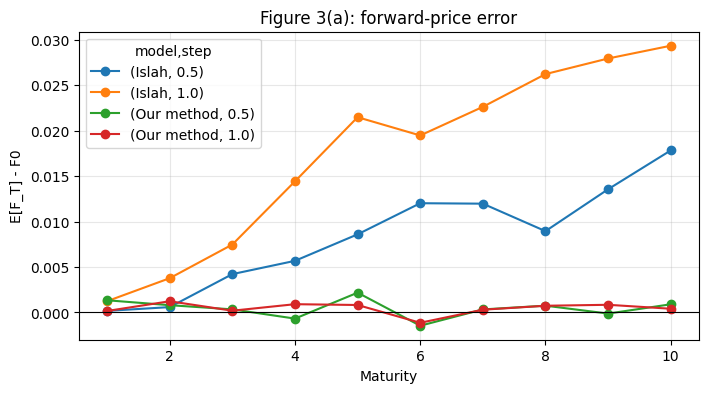

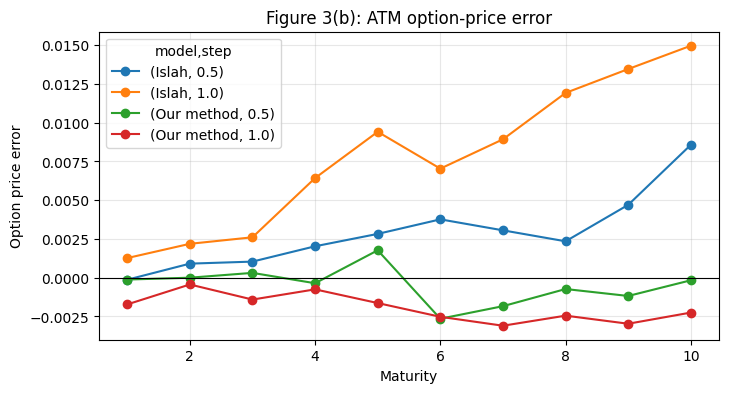

In [22]:
import matplotlib.pyplot as plt

ax = pivot_forward.plot(figsize=(8, 4), marker='o', title='Figure 3(a): forward-price error')
ax.axhline(0.0, color='black', linewidth=0.8)
ax.set_xlabel('Maturity')
ax.set_ylabel('E[F_T] - F0')
ax.grid(True, alpha=0.3)
plt.show()

ax = pivot_option.plot(figsize=(8, 4), marker='o', title='Figure 3(b): ATM option-price error')
ax.axhline(0.0, color='black', linewidth=0.8)
ax.set_xlabel('Maturity')
ax.set_ylabel('Option price error')
ax.grid(True, alpha=0.3)
plt.show()

## 14. Validation Summary

Start with quick mode. The paper-scale run is much slower.


In [21]:
validation_quick = run_full_validation(quick_mode=True)
pd.Series({
    'table1_status': validation_quick['table1_status'],
    'table2_status': validation_quick['table2_status'],
    'overall_conclusion': validation_quick['overall_conclusion'],
    'replication_conclusion': validation_quick['replication_conclusion'],
})


======== SABR REPLICATION VALIDATION ========
Run mode: quick smoke test

Martingale test:
mean |z| = 0.640, max |z| = 1.707, conclusion = Monte Carlo noise dominated

Table 1:
FAIL
Relative errors exceed 1% (max 2.0828%, avg 1.1883%). Step-size trend is broadly consistent with decreasing bias once Monte Carlo standard error is taken into account.

Table 2:
WARNING
Average relative error by rho: rho=0: 1.7793%, rho=0.75: 2.5014%, rho=1: 2.3118%. rho=0 has the smallest average error. Average error does not increase monotonically with rho. Step-size trend is broadly consistent across rho/nu/beta groups; only a few bias increases rise above Monte Carlo noise (worst increase 7.97 standard errors).

Conclusion:
- Potential issues detected
- Result may be dominated by Monte Carlo noise; rerun at paper scale before diagnosing systematic issues.


table1_status                                                          FAIL
table2_status                                                       WARNING
overall_conclusion                                Potential issues detected
replication_conclusion    Result may be dominated by Monte Carlo noise; ...
dtype: object

In [22]:
# Uncomment this only when you want the full validation sweep.
# validation_full = run_full_validation(quick_mode=False)
# pd.Series({
#     'table1_status': validation_full['table1_status'],
#     'table2_status': validation_full['table2_status'],
#     'overall_conclusion': validation_full['overall_conclusion'],
#     'replication_conclusion': validation_full['replication_conclusion'],
# })


## 15. Optional CSV Export Helpers

Use these after running the sections you care about.


In [23]:
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'notebook_exports'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR


WindowsPath('c:/Users/zhyim/Desktop/quant/Numeric Method/numerical-project-main/numerical-project-main/numerical-project-main/outputs/notebook_exports')

In [24]:
# Example exports. Uncomment what you need.
# table1_df.to_csv(OUTPUT_DIR / 'table1.csv', index=False)
# table2_df.to_csv(OUTPUT_DIR / 'table2.csv', index=False)
# table4_df.to_csv(OUTPUT_DIR / 'table4.csv', index=False)
# table5_df.to_csv(OUTPUT_DIR / 'table5.csv', index=False)
# table6_df.to_csv(OUTPUT_DIR / 'table6.csv', index=False)
# table7_df.to_csv(OUTPUT_DIR / 'table7.csv', index=False)
# figure1_df.to_csv(OUTPUT_DIR / 'figure1_dataset.csv', index=False)
# figure3_df.to_csv(OUTPUT_DIR / 'figure3_dataset.csv', index=False)
